# EconML Tutorial 11: Instrumental Variables With DMLIV, OrthoIV, And DeepIV Concepts

Most notebooks so far assumed that all confounders needed for adjustment were observed. Instrumental-variable methods are for a harder situation: the treatment is confounded by something we do not observe, but we have an external source of treatment variation that can act like an instrument.

An instrument is a variable that changes treatment assignment or treatment intensity, but affects the outcome only through that treatment. In product, marketplace, operations, or policy settings, instruments often look like encouragements, eligibility thresholds, randomized supply shocks, rollout timing, or assignment rules.

This notebook teaches the IV workflow with synthetic data where we know the hidden confounder and true treatment effect. The model will not be allowed to use the hidden confounder. That lets us see why ordinary DML is biased and why IV estimators can be closer to the truth when the instrument assumptions are valid.

The installed EconML version in this environment includes `DMLIV`, `OrthoIV`, and `NonParamDMLIV`. It does not include a runnable `DeepIV` module or neural-network backend, so the DeepIV portion is a concept and capability section rather than executable neural-network training.

## Learning Goals

By the end of this notebook, you should be able to:

- explain why IV methods are useful when treatment is endogenous;
- distinguish observed confounding from unobserved confounding;
- define instrument relevance, independence, exclusion, and monotonicity assumptions;
- diagnose first-stage instrument strength with residualized treatment and instrument signals;
- compare naive DML with IV-oriented estimators;
- fit `DMLIV`, `OrthoIV`, and `NonParamDMLIV` on a continuous-treatment IV example;
- evaluate CATE recovery against synthetic truth;
- understand when DeepIV-style methods are conceptually appropriate;
- explain why weak or invalid instruments can be worse than no instrument at all.

## Tutorial Flow

The notebook proceeds in six stages:

1. Define the IV assumptions and draw the causal structure.
2. Create synthetic data with an unobserved confounder, a valid instrument, and heterogeneous treatment effects.
3. Show why naive adjustment is biased when the hidden confounder is omitted.
4. Diagnose instrument strength and support.
5. Fit and compare `DMLIV`, `OrthoIV`, `NonParamDMLIV`, and a naive `LinearDML` baseline.
6. Discuss DeepIV conceptually and summarize practical reporting checks.

The notebook is intentionally synthetic because real datasets do not reveal the hidden confounder or the true CATE.

## Setup

This cell imports the packages used in the notebook, creates output folders, and sets plotting defaults. The warning filters remove optional widget and pandas-to-NumPy conversion messages so the saved notebook remains clean.

In [1]:
from pathlib import Path
import importlib.util
import os
import warnings

# Suppress optional widget warnings that can appear while importing EconML in headless notebook runs.
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import econml
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

from econml.dml import LinearDML
from econml.iv.dml import DMLIV, NonParamDMLIV, OrthoIV

warnings.filterwarnings("ignore", message="X does not have valid feature names.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Not all column names are strings.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Co-variance matrix is underdetermined.*", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11


def find_project_root(start=None):
    """Find the repository root from either the repo or a nested notebook folder."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "econml"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(202611)

print(f"Project root: {PROJECT_ROOT}")
print(f"EconML version: {econml.__version__}")
print(f"Figures will be saved to: {FIGURE_DIR.relative_to(PROJECT_ROOT)}")
print(f"Tables will be saved to: {TABLE_DIR.relative_to(PROJECT_ROOT)}")

Project root: /home/apex/Documents/ranking_sys
EconML version: 0.16.0
Figures will be saved to: notebooks/tutorials/econml/outputs/figures
Tables will be saved to: notebooks/tutorials/econml/outputs/tables


The environment is ready. Every output produced here will use the `11_` prefix so the IV tutorial artifacts are easy to find later.

## IV Vocabulary

Instrumental-variable estimation is mostly about the design before it is about the estimator. This table defines the core objects in the notebook.

In [2]:
iv_vocabulary = pd.DataFrame(
    [
        {
            "term": "Treatment T",
            "meaning": "The intervention, exposure, dose, or intensity whose effect we want to estimate.",
            "notebook_example": "Treatment intensity chosen partly by user need and hidden motivation.",
        },
        {
            "term": "Outcome Y",
            "meaning": "The post-treatment result of interest.",
            "notebook_example": "Continuous value metric after treatment intensity is realized.",
        },
        {
            "term": "Observed covariates X",
            "meaning": "Pre-treatment variables the analyst can adjust for.",
            "notebook_example": "Need, engagement, friction, affinity, tenure, and region risk.",
        },
        {
            "term": "Hidden confounder U",
            "meaning": "Unobserved cause of both treatment and outcome.",
            "notebook_example": "Motivation or latent demand that raises treatment intensity and outcome.",
        },
        {
            "term": "Instrument Z",
            "meaning": "A source of treatment variation that affects outcome only through treatment.",
            "notebook_example": "Encouragement intensity that shifts treatment but has no direct outcome effect.",
        },
        {
            "term": "First stage",
            "meaning": "Relationship between the instrument and treatment after adjusting for X.",
            "notebook_example": "Residualized encouragement predicts residualized treatment intensity.",
        },
        {
            "term": "Local or complier effect",
            "meaning": "The effect identified for units whose treatment responds to the instrument.",
            "notebook_example": "Rows whose treatment intensity changes when encouragement changes.",
        },
    ]
)

iv_vocabulary.to_csv(TABLE_DIR / "11_iv_vocabulary.csv", index=False)
display(iv_vocabulary)

,term,meaning,notebook_example
0,Treatment T,"The intervention, exposure, dose, or intensity...",Treatment intensity chosen partly by user need...
1,Outcome Y,The post-treatment result of interest.,Continuous value metric after treatment intens...
2,Observed covariates X,Pre-treatment variables the analyst can adjust...,"Need, engagement, friction, affinity, tenure, ..."
3,Hidden confounder U,Unobserved cause of both treatment and outcome.,Motivation or latent demand that raises treatm...
4,Instrument Z,A source of treatment variation that affects o...,Encouragement intensity that shifts treatment ...
5,First stage,Relationship between the instrument and treatm...,Residualized encouragement predicts residualiz...
6,Local or complier effect,The effect identified for units whose treatmen...,Rows whose treatment intensity changes when en...


This vocabulary keeps the IV discussion precise. The instrument is not another confounder to control for; it is a source of treatment variation used to isolate causal signal.

## IV Assumptions

A valid instrument must satisfy assumptions that cannot be proven from the observed data alone. Diagnostics can support the case for an instrument, but the design argument is still essential.

In [3]:
iv_assumptions = pd.DataFrame(
    [
        {
            "assumption": "Relevance",
            "plain_language": "The instrument changes treatment after adjusting for observed covariates.",
            "observable_check": "First-stage coefficient, partial R-squared, residualized Z versus residualized T plot.",
            "failure_mode": "Weak instruments produce noisy and unstable IV estimates.",
        },
        {
            "assumption": "Independence",
            "plain_language": "The instrument is as-if random conditional on observed covariates.",
            "observable_check": "Balance checks and design documentation, not a definitive statistical test.",
            "failure_mode": "If Z is correlated with hidden confounders, IV estimates can be biased.",
        },
        {
            "assumption": "Exclusion",
            "plain_language": "The instrument affects the outcome only through treatment.",
            "observable_check": "Substantive design argument and placebo outcomes where possible.",
            "failure_mode": "A direct Z -> Y path contaminates the IV contrast.",
        },
        {
            "assumption": "Monotonicity or no defiers",
            "plain_language": "The instrument pushes treatment in a consistent direction for relevant units.",
            "observable_check": "Usually argued from design, especially for encouragements or eligibility thresholds.",
            "failure_mode": "If some units move opposite the instrument, the estimand becomes hard to interpret.",
        },
    ]
)

iv_assumptions.to_csv(TABLE_DIR / "11_iv_assumptions.csv", index=False)
display(iv_assumptions)

,assumption,plain_language,observable_check,failure_mode
0,Relevance,The instrument changes treatment after adjusti...,"First-stage coefficient, partial R-squared, re...",Weak instruments produce noisy and unstable IV...
1,Independence,The instrument is as-if random conditional on ...,"Balance checks and design documentation, not a...","If Z is correlated with hidden confounders, IV..."
2,Exclusion,The instrument affects the outcome only throug...,Substantive design argument and placebo outcom...,A direct Z -> Y path contaminates the IV contr...
3,Monotonicity or no defiers,The instrument pushes treatment in a consisten...,"Usually argued from design, especially for enc...","If some units move opposite the instrument, th..."


The first assumption can be partly checked with data. The other assumptions mostly come from how the instrument was created and whether direct outcome paths are plausible.

## Causal Structure

The diagram below shows the IV design. The hidden confounder affects both treatment and outcome. The instrument affects treatment, and treatment affects outcome. A valid instrument should not have a direct arrow to the outcome and should not be caused by the hidden confounder.

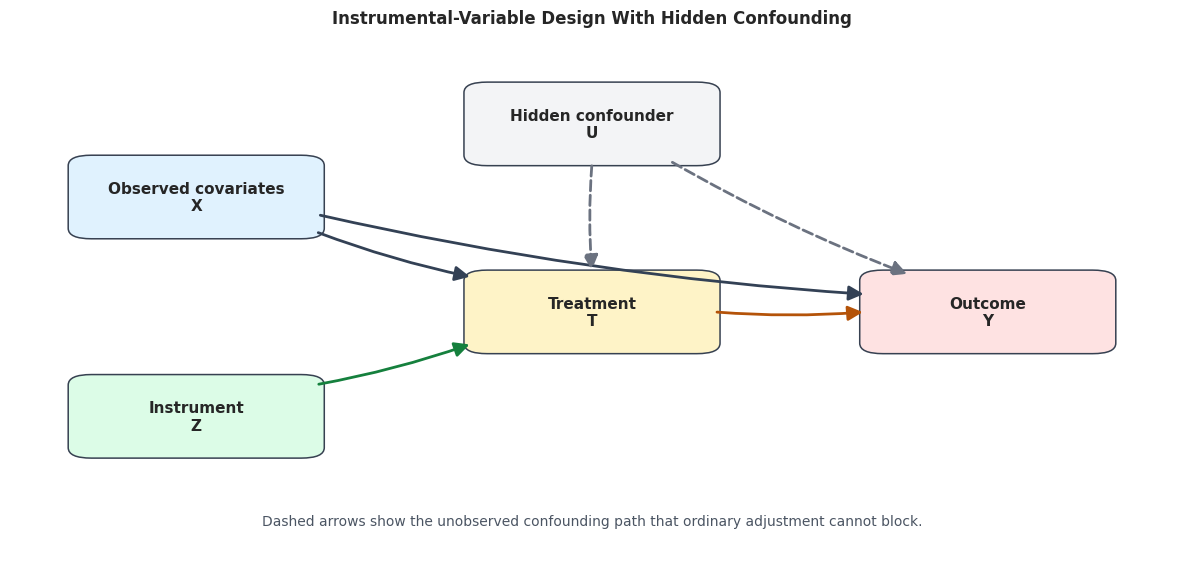

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()

# Fix the drawing canvas to a normalized coordinate system. This prevents
# Matplotlib from clipping patches or autoscaling in a way that hides arrows.
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

nodes = {
    "X": {"xy": (0.16, 0.72), "label": "Observed covariates\nX", "color": "#e0f2fe"},
    "Z": {"xy": (0.16, 0.30), "label": "Instrument\nZ", "color": "#dcfce7"},
    "T": {"xy": (0.50, 0.50), "label": "Treatment\nT", "color": "#fef3c7"},
    "Y": {"xy": (0.84, 0.50), "label": "Outcome\nY", "color": "#fee2e2"},
    "U": {"xy": (0.50, 0.86), "label": "Hidden confounder\nU", "color": "#f3f4f6"},
}
box_w, box_h = 0.18, 0.12


def box_edge_point(start_xy, end_xy, leaving=True, pad=0.015):
    """Return the point where a center-to-center arrow meets a rectangular box edge."""
    x0, y0 = start_xy
    x1, y1 = end_xy
    dx, dy = x1 - x0, y1 - y0
    distance = np.hypot(dx, dy)
    if distance == 0:
        return x0, y0

    # Scale the direction vector until it reaches the rectangle boundary.
    scale = 0.5 / max(abs(dx) / box_w, abs(dy) / box_h)
    unit_x, unit_y = dx / distance, dy / distance

    if leaving:
        return x0 + dx * scale + pad * unit_x, y0 + dy * scale + pad * unit_y
    return x0 - dx * scale - pad * unit_x, y0 - dy * scale - pad * unit_y


# Draw boxes first, then draw arrows between box edges. The arrows are not
# hidden under the text because their endpoints stop at the node boundaries.
for spec in nodes.values():
    x, y = spec["xy"]
    rect = FancyBboxPatch(
        (x - box_w / 2, y - box_h / 2),
        box_w,
        box_h,
        boxstyle="round,pad=0.02",
        facecolor=spec["color"],
        edgecolor="#374151",
        linewidth=1.1,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, y, spec["label"], ha="center", va="center", fontsize=11, fontweight="bold", zorder=4)

edge_specs = [
    ("X", "T", "#334155", "solid"),
    ("X", "Y", "#334155", "solid"),
    ("Z", "T", "#15803d", "solid"),
    ("T", "Y", "#b45309", "solid"),
    ("U", "T", "#6b7280", "dashed"),
    ("U", "Y", "#6b7280", "dashed"),
]

for start, end, color, style in edge_specs:
    start_xy = nodes[start]["xy"]
    end_xy = nodes[end]["xy"]
    arrow_start = box_edge_point(start_xy, end_xy, leaving=True)
    arrow_end = box_edge_point(end_xy, start_xy, leaving=True)
    arrow = FancyArrowPatch(
        arrow_start,
        arrow_end,
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=2.0,
        color=color,
        linestyle=style,
        zorder=5,
        connectionstyle="arc3,rad=0.04",
    )
    ax.add_patch(arrow)

ax.text(
    0.50,
    0.10,
    "Dashed arrows show the unobserved confounding path that ordinary adjustment cannot block.",
    ha="center",
    va="center",
    fontsize=10,
    color="#4b5563",
)
ax.set_title("Instrumental-Variable Design With Hidden Confounding", pad=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_iv_design_dag.png", dpi=160, bbox_inches="tight")
plt.show()

The diagram explains the motivation for IV. If `U` were observed, we could adjust for it. Because it is hidden, we need the instrument to isolate treatment variation that is not driven by `U`.

## DeepIV Capability Check

DeepIV is a neural-network IV approach designed for flexible continuous treatment settings. Some EconML installations historically exposed it through neural-network modules, but this environment does not include that module or a TensorFlow backend. The check below makes that explicit so the tutorial does not silently depend on missing packages.

In [5]:
try:
    deepiv_spec = importlib.util.find_spec("econml.iv.nnet")
    deepiv_module_available = deepiv_spec is not None
except Exception:
    deepiv_module_available = False

deepiv_capability = pd.DataFrame(
    [
        {
            "capability": "econml.iv.nnet module available",
            "available": deepiv_module_available,
            "note": "Required for a runnable DeepIV-style EconML example in this environment.",
        },
        {
            "capability": "tensorflow package available",
            "available": importlib.util.find_spec("tensorflow") is not None,
            "note": "Usually needed for neural-network treatment and outcome models.",
        },
        {
            "capability": "keras package available",
            "available": importlib.util.find_spec("keras") is not None,
            "note": "Often used as a high-level neural-network API.",
        },
        {
            "capability": "DMLIV available",
            "available": DMLIV is not None,
            "note": "This is the main runnable IV estimator used below.",
        },
        {
            "capability": "OrthoIV available",
            "available": OrthoIV is not None,
            "note": "This is a second runnable IV estimator used below.",
        },
    ]
)

deepiv_capability.to_csv(TABLE_DIR / "11_deepiv_capability_check.csv", index=False)
display(deepiv_capability)

,capability,available,note
0,econml.iv.nnet module available,False,Required for a runnable DeepIV-style EconML ex...
1,tensorflow package available,False,Usually needed for neural-network treatment an...
2,keras package available,False,Often used as a high-level neural-network API.
3,DMLIV available,True,This is the main runnable IV estimator used be...
4,OrthoIV available,True,This is a second runnable IV estimator used be...


The capability check tells us how to structure the notebook. We will teach DeepIV conceptually, while the executable estimator work uses the IV classes that are available in the installed EconML package.

## DeepIV Concept Map

This table summarizes when a DeepIV-style method is useful and how it differs from the DMLIV examples we can run locally.

In [6]:
deepiv_concept_map = pd.DataFrame(
    [
        {
            "component": "Use case",
            "deepiv_view": "Flexible continuous treatment with potentially nonlinear treatment response.",
            "dmliv_view": "Orthogonalized IV estimation with machine-learning nuisance models and a final CATE model.",
        },
        {
            "component": "First stage",
            "deepiv_view": "Model the full treatment distribution p(T | X, Z).",
            "dmliv_view": "Model expected treatment using X and Z, plus expected treatment using X alone.",
        },
        {
            "component": "Second stage",
            "deepiv_view": "Learn an outcome response by integrating over treatment draws from the first stage.",
            "dmliv_view": "Use residualized treatment variation induced by the instrument to estimate effects.",
        },
        {
            "component": "Practical requirements",
            "deepiv_view": "Neural-network backend, careful tuning, and enough data for flexible density and outcome models.",
            "dmliv_view": "Works with standard scikit-learn nuisance models and can be easier to audit.",
        },
        {
            "component": "This notebook",
            "deepiv_view": "Conceptual discussion only because the local module/backend is absent.",
            "dmliv_view": "Fully executable examples with synthetic ground truth.",
        },
    ]
)

deepiv_concept_map.to_csv(TABLE_DIR / "11_deepiv_concept_map.csv", index=False)
display(deepiv_concept_map)

,component,deepiv_view,dmliv_view
0,Use case,Flexible continuous treatment with potentially...,Orthogonalized IV estimation with machine-lear...
1,First stage,"Model the full treatment distribution p(T | X,...","Model expected treatment using X and Z, plus e..."
2,Second stage,Learn an outcome response by integrating over ...,Use residualized treatment variation induced b...
3,Practical requirements,"Neural-network backend, careful tuning, and en...",Works with standard scikit-learn nuisance mode...
4,This notebook,Conceptual discussion only because the local m...,Fully executable examples with synthetic groun...


DeepIV is useful to know because it broadens the IV toolkit, but the identification assumptions are the same. A neural network cannot rescue an invalid instrument.

## Teaching Data Design

The synthetic data below includes an unobserved confounder `hidden_motivation`. This hidden variable affects both treatment intensity and outcome. The instrument `encouragement_score` shifts treatment intensity but does not directly affect the outcome.

The estimator will only receive observed covariates, treatment, instrument, and outcome. It will not receive `hidden_motivation`.

In [7]:
def true_iv_effect(frame):
    """Ground-truth one-unit treatment effect for the IV teaching data."""
    return (
        0.45
        + 0.26 * frame["baseline_need"]
        - 0.18 * frame["friction_score"]
        + 0.17 * frame["content_affinity"]
        - 0.14 * frame["price_sensitivity"]
        + 0.15 * frame["high_need_segment"]
        - 0.12 * frame["region_risk"]
    )


n_iv = 3_600
baseline_need = rng.normal(0, 1, size=n_iv)
prior_engagement = rng.normal(0, 1, size=n_iv)
friction_score = rng.normal(0, 1, size=n_iv)
content_affinity = rng.normal(0, 1, size=n_iv)
price_sensitivity = rng.beta(2.2, 3.1, size=n_iv)
account_tenure = rng.gamma(shape=3.0, scale=18.0, size=n_iv)
region_risk = rng.binomial(1, 0.28, size=n_iv)
high_need_segment = (baseline_need > 0.55).astype(int)
hidden_motivation = rng.normal(0, 1, size=n_iv)

observed_features = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "content_affinity": content_affinity,
        "price_sensitivity": price_sensitivity,
        "account_tenure": account_tenure,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
    }
)

true_tau = true_iv_effect(observed_features)

# The instrument can depend on observed covariates, but not on the hidden confounder after conditioning on X.
encouragement_score = (
    0.35 * baseline_need
    - 0.22 * friction_score
    + 0.18 * content_affinity
    + rng.normal(0, 1.0, size=n_iv)
)

first_stage_strength = 0.72
treatment_intensity = (
    0.90
    + first_stage_strength * encouragement_score
    + 0.42 * baseline_need
    + 0.36 * prior_engagement
    - 0.24 * friction_score
    - 0.20 * price_sensitivity
    + 0.88 * hidden_motivation
    + rng.normal(0, 0.85, size=n_iv)
)

base_outcome = (
    1.10
    + 0.55 * baseline_need
    + 0.42 * prior_engagement
    - 0.30 * friction_score
    + 0.22 * content_affinity
    - 0.18 * price_sensitivity
    + 0.10 * np.log1p(account_tenure)
    - 0.16 * region_risk
)
outcome = base_outcome + true_tau * treatment_intensity + 1.25 * hidden_motivation + rng.normal(0, 0.80, size=n_iv)

iv_df = observed_features.assign(
    encouragement_score=encouragement_score,
    treatment_intensity=treatment_intensity,
    outcome=outcome,
    true_tau=true_tau,
    hidden_motivation=hidden_motivation,
)

iv_df.to_csv(TABLE_DIR / "11_iv_teaching_data_with_hidden_truth.csv", index=False)
iv_df.head()

,baseline_need,prior_engagement,friction_score,content_affinity,price_sensitivity,account_tenure,region_risk,high_need_segment,encouragement_score,treatment_intensity,outcome,true_tau,hidden_motivation
0,1.544038,-1.149893,-0.669504,0.895210,0.433388,47.444103,0,1,1.347781,0.969740,4.029751,1.213472,-0.750346
1,2.086923,0.005095,-0.077179,0.199264,0.520302,52.476578,1,1,0.668905,2.995120,6.133274,0.997525,1.164015
2,0.997742,-2.452715,0.583426,-1.623985,0.223627,60.534771,1,1,0.232150,0.466525,1.361623,0.327011,0.984966
3,1.091888,-0.846099,-1.083608,-0.340887,0.214274,100.129944,0,1,1.171110,3.581100,7.000171,0.990991,1.199687
4,0.096802,-0.599986,-2.990761,0.255035,0.155816,30.856476,0,0,0.353425,0.936855,-0.085447,1.035047,-2.177572


The first rows include the hidden confounder for teaching purposes. The models below will not use that column. In real data, the hidden confounder is exactly the thing we do not get to observe.

## Field Dictionary

This table describes every field in the IV teaching data and identifies which columns are allowed into the model and which are teaching-only truth.

In [8]:
iv_field_dictionary = pd.DataFrame(
    [
        ("baseline_need", "Observed covariate", "Pre-treatment need or demand signal used by the model."),
        ("prior_engagement", "Observed covariate", "Pre-treatment engagement used by the model."),
        ("friction_score", "Observed covariate", "Pre-treatment friction signal used by the model."),
        ("content_affinity", "Observed covariate", "Pre-treatment match or affinity signal used by the model."),
        ("price_sensitivity", "Observed covariate", "Pre-treatment sensitivity to cost or effort."),
        ("account_tenure", "Observed covariate", "Age of the account or relationship in weeks."),
        ("region_risk", "Observed covariate", "Binary marker for lower baseline outcome regions."),
        ("high_need_segment", "Observed covariate", "Binary segment derived from baseline need."),
        ("encouragement_score", "Instrument", "Source of treatment variation used for IV identification."),
        ("treatment_intensity", "Treatment", "Endogenous continuous treatment whose effect is estimated."),
        ("outcome", "Outcome", "Observed post-treatment outcome."),
        ("true_tau", "Teaching-only truth", "Known treatment effect for each row."),
        ("hidden_motivation", "Teaching-only hidden confounder", "Unobserved cause of both treatment and outcome, excluded from model inputs."),
    ],
    columns=["field", "role", "description"],
)

iv_field_dictionary.to_csv(TABLE_DIR / "11_iv_field_dictionary.csv", index=False)
display(iv_field_dictionary)

,field,role,description
0,baseline_need,Observed covariate,Pre-treatment need or demand signal used by th...
1,prior_engagement,Observed covariate,Pre-treatment engagement used by the model.
2,friction_score,Observed covariate,Pre-treatment friction signal used by the model.
3,content_affinity,Observed covariate,Pre-treatment match or affinity signal used by...
4,price_sensitivity,Observed covariate,Pre-treatment sensitivity to cost or effort.
5,account_tenure,Observed covariate,Age of the account or relationship in weeks.
6,region_risk,Observed covariate,Binary marker for lower baseline outcome regions.
7,high_need_segment,Observed covariate,Binary segment derived from baseline need.
8,encouragement_score,Instrument,Source of treatment variation used for IV iden...
9,treatment_intensity,Treatment,Endogenous continuous treatment whose effect i...


The model will use `encouragement_score` as the instrument and will exclude `hidden_motivation`. This is what creates the need for IV methods.

## Basic Summary

This cell summarizes the sample, treatment, instrument, outcome, true effect, and hidden confounder. The hidden confounder appears only because this is a controlled teaching example.

In [9]:
iv_basic_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "instrument_mean",
            "instrument_std",
            "treatment_mean",
            "treatment_std",
            "outcome_mean",
            "outcome_std",
            "true_ate",
            "true_tau_std",
            "hidden_motivation_mean",
            "hidden_motivation_std",
        ],
        "value": [
            len(iv_df),
            iv_df.shape[1],
            iv_df["encouragement_score"].mean(),
            iv_df["encouragement_score"].std(),
            iv_df["treatment_intensity"].mean(),
            iv_df["treatment_intensity"].std(),
            iv_df["outcome"].mean(),
            iv_df["outcome"].std(),
            iv_df["true_tau"].mean(),
            iv_df["true_tau"].std(),
            iv_df["hidden_motivation"].mean(),
            iv_df["hidden_motivation"].std(),
        ],
    }
)

iv_basic_summary.to_csv(TABLE_DIR / "11_iv_basic_summary.csv", index=False)
display(iv_basic_summary)

,metric,value
0,rows,3600.000000
1,columns,13.000000
2,instrument_mean,-0.008230
3,instrument_std,1.131338
4,treatment_mean,0.798052
5,treatment_std,1.708083
6,outcome_mean,2.012462
7,outcome_std,2.536290
8,true_ate,0.392660
9,true_tau_std,0.408619


The true treatment effect varies across rows, and the treatment has substantial variation. That makes this a heterogeneous continuous-treatment IV problem rather than a simple constant-effect IV example.

## True Effect Distribution

The true CATE distribution is available only because the data are synthetic. It gives us the target that IV estimators should recover.

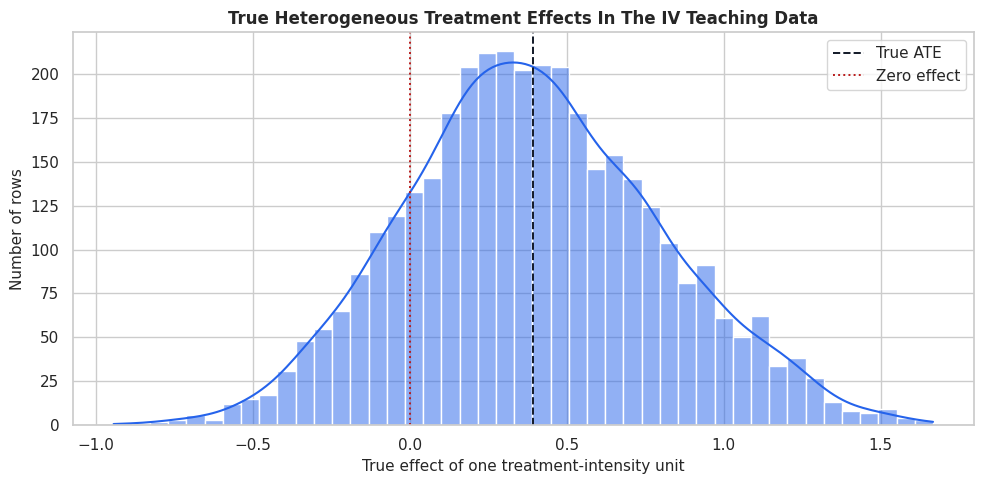

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(iv_df["true_tau"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(iv_df["true_tau"].mean(), color="#111827", linestyle="--", linewidth=1.4, label="True ATE")
ax.axvline(0, color="#b91c1c", linestyle=":", linewidth=1.4, label="Zero effect")
ax.set_title("True Heterogeneous Treatment Effects In The IV Teaching Data")
ax.set_xlabel("True effect of one treatment-intensity unit")
ax.set_ylabel("Number of rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_true_iv_effect_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

The distribution shows meaningful heterogeneity. The IV estimators below will try to recover this effect function without using the hidden confounder.

## Why Ordinary Adjustment Is Biased

This cell shows the hidden-confounding problem directly. The hidden confounder is correlated with treatment and outcome, so an estimator that adjusts only for observed covariates can mistake hidden motivation for treatment effect.

In [11]:
confounding_diagnostics = pd.DataFrame(
    [
        {
            "relationship": "corr(hidden_motivation, treatment_intensity)",
            "value": np.corrcoef(iv_df["hidden_motivation"], iv_df["treatment_intensity"])[0, 1],
            "why_it_matters": "Hidden motivation changes who receives more treatment.",
        },
        {
            "relationship": "corr(hidden_motivation, outcome)",
            "value": np.corrcoef(iv_df["hidden_motivation"], iv_df["outcome"])[0, 1],
            "why_it_matters": "Hidden motivation also changes the outcome.",
        },
        {
            "relationship": "corr(encouragement_score, hidden_motivation)",
            "value": np.corrcoef(iv_df["encouragement_score"], iv_df["hidden_motivation"])[0, 1],
            "why_it_matters": "A valid instrument should not be related to the hidden confounder.",
        },
        {
            "relationship": "corr(encouragement_score, treatment_intensity)",
            "value": np.corrcoef(iv_df["encouragement_score"], iv_df["treatment_intensity"])[0, 1],
            "why_it_matters": "A relevant instrument should shift treatment.",
        },
    ]
)

confounding_diagnostics.to_csv(TABLE_DIR / "11_hidden_confounding_diagnostics.csv", index=False)
display(confounding_diagnostics)

,relationship,value,why_it_matters
0,"corr(hidden_motivation, treatment_intensity)",0.533501,Hidden motivation changes who receives more tr...
1,"corr(hidden_motivation, outcome)",0.654907,Hidden motivation also changes the outcome.
2,"corr(encouragement_score, hidden_motivation)",0.031887,A valid instrument should not be related to th...
3,"corr(encouragement_score, treatment_intensity)",0.609347,A relevant instrument should shift treatment.


The hidden confounder is strongly related to treatment and outcome, while the instrument is designed to be nearly unrelated to the hidden confounder. That is exactly the pattern an IV design needs.

## Instrument And Treatment Distributions

Before fitting any model, we inspect the instrument and treatment distributions. An instrument with almost no variation cannot identify a useful first stage.

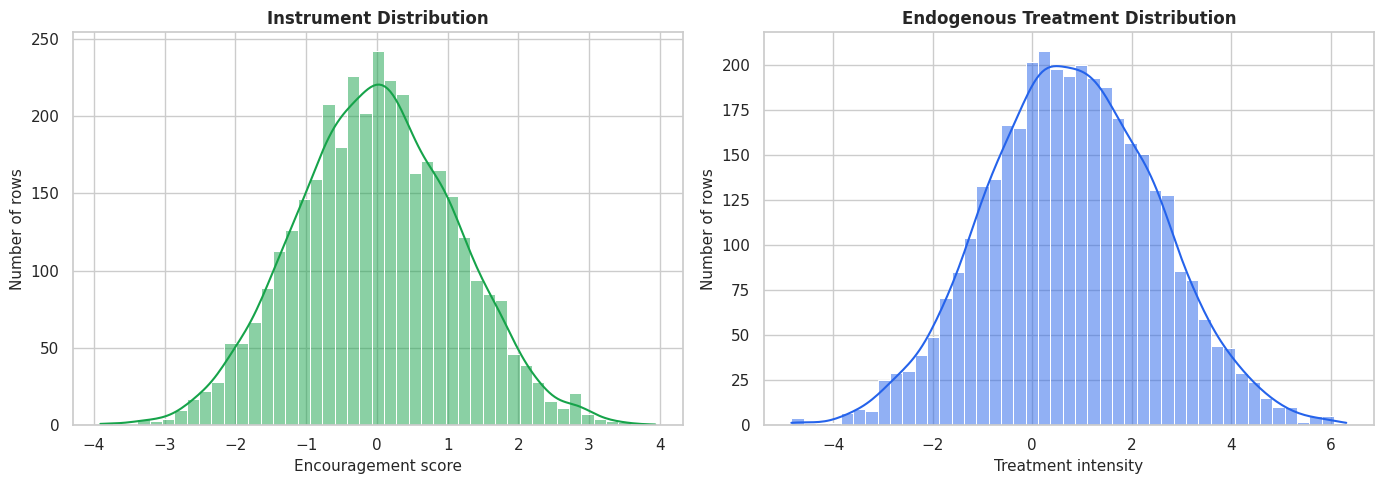

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(iv_df["encouragement_score"], bins=45, kde=True, color="#16a34a", ax=axes[0])
axes[0].set_title("Instrument Distribution")
axes[0].set_xlabel("Encouragement score")
axes[0].set_ylabel("Number of rows")

sns.histplot(iv_df["treatment_intensity"], bins=45, kde=True, color="#2563eb", ax=axes[1])
axes[1].set_title("Endogenous Treatment Distribution")
axes[1].set_xlabel("Treatment intensity")
axes[1].set_ylabel("Number of rows")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_instrument_and_treatment_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

Both variables have useful variation. The next question is whether the instrument predicts treatment after removing the part explained by observed covariates.

## Train-Test Split

We split the data before fitting models so the recovery diagnostics are evaluated on held-out rows. The split is random because treatment and instrument are continuous.

In [13]:
iv_feature_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "content_affinity",
    "price_sensitivity",
    "account_tenure",
    "region_risk",
    "high_need_segment",
]

iv_train, iv_test = train_test_split(iv_df, test_size=0.35, random_state=202611)
iv_train = iv_train.reset_index(drop=True)
iv_test = iv_test.reset_index(drop=True)

iv_split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(iv_train), len(iv_test)],
        "instrument_mean": [iv_train["encouragement_score"].mean(), iv_test["encouragement_score"].mean()],
        "treatment_mean": [iv_train["treatment_intensity"].mean(), iv_test["treatment_intensity"].mean()],
        "outcome_mean": [iv_train["outcome"].mean(), iv_test["outcome"].mean()],
        "true_ate": [iv_train["true_tau"].mean(), iv_test["true_tau"].mean()],
        "hidden_motivation_mean": [iv_train["hidden_motivation"].mean(), iv_test["hidden_motivation"].mean()],
    }
)

iv_split_summary.to_csv(TABLE_DIR / "11_iv_train_test_split_summary.csv", index=False)
display(iv_split_summary)

,split,rows,instrument_mean,treatment_mean,outcome_mean,true_ate,hidden_motivation_mean
0,train,2340,0.005206,0.802403,2.005219,0.385969,0.003911
1,test,1260,-0.033182,0.789971,2.025914,0.405085,0.027069


The train and test splits have similar means for the key variables. That keeps later held-out comparisons from being dominated by split imbalance.

## Model Matrices

This cell creates the exact arrays passed to EconML. Notice that `hidden_motivation` is deliberately excluded from `X`.

In [14]:
X_iv_train = iv_train[iv_feature_cols].copy()
X_iv_test = iv_test[iv_feature_cols].copy()
T_iv_train = iv_train["treatment_intensity"].to_numpy()
T_iv_test = iv_test["treatment_intensity"].to_numpy()
Z_iv_train = iv_train["encouragement_score"].to_numpy()
Z_iv_test = iv_test["encouragement_score"].to_numpy()
y_iv_train = iv_train["outcome"].to_numpy()
y_iv_test = iv_test["outcome"].to_numpy()
true_tau_iv_test = iv_test["true_tau"].to_numpy()

iv_matrix_summary = pd.DataFrame(
    {
        "object": ["X_iv_train", "X_iv_test", "T_iv_train", "Z_iv_train", "y_iv_train"],
        "shape_or_length": [X_iv_train.shape, X_iv_test.shape, len(T_iv_train), len(Z_iv_train), len(y_iv_train)],
        "description": [
            "Observed covariates used for heterogeneity and adjustment.",
            "Held-out observed covariates for evaluation.",
            "Endogenous treatment intensity.",
            "Instrumental encouragement score.",
            "Observed outcome.",
        ],
    }
)

iv_matrix_summary.to_csv(TABLE_DIR / "11_iv_model_matrix_summary.csv", index=False)
display(iv_matrix_summary)

,object,shape_or_length,description
0,X_iv_train,"(2340, 8)",Observed covariates used for heterogeneity and...
1,X_iv_test,"(1260, 8)",Held-out observed covariates for evaluation.
2,T_iv_train,2340,Endogenous treatment intensity.
3,Z_iv_train,2340,Instrumental encouragement score.
4,y_iv_train,2340,Observed outcome.


The instrument `Z` is passed separately from the observed covariates `X`. That separation is central to the EconML IV estimator interface.

## Residualized First Stage

Instrument relevance should be checked after adjusting for observed covariates. This cell residualizes both treatment and instrument on `X`, then estimates the relationship between residualized instrument and residualized treatment.

In [15]:
def residualized_first_stage(X, T, Z):
    """Residualize T and Z on X, then regress residualized T on residualized Z."""
    t_on_x = LinearRegression().fit(X, T)
    z_on_x = LinearRegression().fit(X, Z)
    t_resid = T - t_on_x.predict(X)
    z_resid = Z - z_on_x.predict(X)
    sxx = np.sum((z_resid - z_resid.mean()) ** 2)
    beta = np.sum((z_resid - z_resid.mean()) * (t_resid - t_resid.mean())) / sxx
    intercept = t_resid.mean() - beta * z_resid.mean()
    fitted = intercept + beta * z_resid
    resid = t_resid - fitted
    sigma2 = np.sum(resid**2) / (len(T) - 2)
    se = np.sqrt(sigma2 / sxx)
    t_stat = beta / se
    partial_r2 = np.corrcoef(t_resid, z_resid)[0, 1] ** 2
    return {
        "beta": beta,
        "standard_error": se,
        "t_stat": t_stat,
        "f_stat": t_stat**2,
        "partial_r2": partial_r2,
        "t_resid": t_resid,
        "z_resid": z_resid,
        "t_model": t_on_x,
        "z_model": z_on_x,
    }


first_stage = residualized_first_stage(X_iv_train, T_iv_train, Z_iv_train)
first_stage_summary = pd.DataFrame(
    [
        {
            "diagnostic": "residualized_first_stage_beta",
            "value": first_stage["beta"],
            "meaning": "Change in residualized treatment for one unit of residualized instrument.",
        },
        {
            "diagnostic": "first_stage_f_stat",
            "value": first_stage["f_stat"],
            "meaning": "Large values indicate stronger instrument relevance.",
        },
        {
            "diagnostic": "partial_r_squared",
            "value": first_stage["partial_r2"],
            "meaning": "Share of residual treatment variation explained by residual instrument.",
        },
    ]
)

first_stage_summary.to_csv(TABLE_DIR / "11_residualized_first_stage_summary.csv", index=False)
display(first_stage_summary)

,diagnostic,value,meaning
0,residualized_first_stage_beta,0.719671,Change in residualized treatment for one unit ...
1,first_stage_f_stat,840.983341,Large values indicate stronger instrument rele...
2,partial_r_squared,0.264545,Share of residual treatment variation explaine...


The first-stage diagnostics show that the instrument has meaningful residual relationship with treatment. This supports relevance, although it does not prove independence or exclusion.

## Residualized First-Stage Plot

The plot below visualizes the first stage after removing the part of treatment and instrument explained by observed covariates.

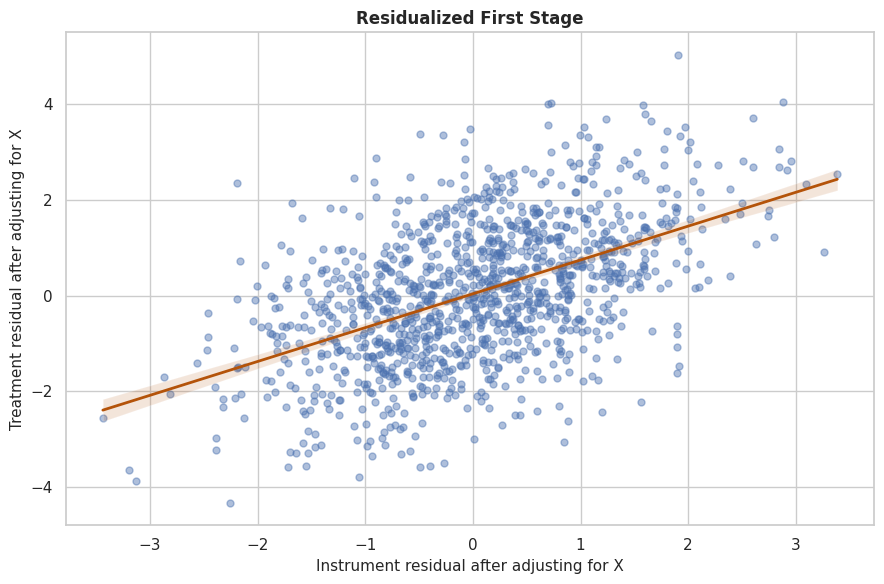

In [16]:
first_stage_plot = pd.DataFrame(
    {
        "residualized_instrument": first_stage["z_resid"],
        "residualized_treatment": first_stage["t_resid"],
    }
).sample(n=min(1_200, len(iv_train)), random_state=202611)

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=first_stage_plot,
    x="residualized_instrument",
    y="residualized_treatment",
    scatter_kws={"alpha": 0.45, "s": 25},
    line_kws={"color": "#b45309", "linewidth": 2},
    ax=ax,
)
ax.set_title("Residualized First Stage")
ax.set_xlabel("Instrument residual after adjusting for X")
ax.set_ylabel("Treatment residual after adjusting for X")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_residualized_first_stage.png", dpi=160, bbox_inches="tight")
plt.show()

The upward slope is the usable treatment variation created by the instrument. IV estimators lean on this variation rather than on treatment variation driven by hidden motivation.

## Nuisance Model Diagnostics

DMLIV uses nuisance models for the outcome, treatment conditional on `X`, and treatment conditional on `X` plus `Z`. The key first-stage idea is that adding the instrument should improve treatment prediction.

In [17]:
t_x_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202612, n_jobs=-1)
t_xz_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202613, n_jobs=-1)
y_x_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202614, n_jobs=-1)

XZ_iv_train = X_iv_train.assign(encouragement_score=Z_iv_train)
XZ_iv_test = X_iv_test.assign(encouragement_score=Z_iv_test)

t_x_model.fit(X_iv_train, T_iv_train)
t_xz_model.fit(XZ_iv_train, T_iv_train)
y_x_model.fit(X_iv_train, y_iv_train)

t_x_pred = t_x_model.predict(X_iv_test)
t_xz_pred = t_xz_model.predict(XZ_iv_test)
y_x_pred = y_x_model.predict(X_iv_test)

nuisance_diagnostics = pd.DataFrame(
    [
        {
            "model": "T ~ X",
            "target": "treatment_intensity",
            "rmse": np.sqrt(mean_squared_error(T_iv_test, t_x_pred)),
            "mae": mean_absolute_error(T_iv_test, t_x_pred),
        },
        {
            "model": "T ~ X + Z",
            "target": "treatment_intensity",
            "rmse": np.sqrt(mean_squared_error(T_iv_test, t_xz_pred)),
            "mae": mean_absolute_error(T_iv_test, t_xz_pred),
        },
        {
            "model": "Y ~ X",
            "target": "outcome",
            "rmse": np.sqrt(mean_squared_error(y_iv_test, y_x_pred)),
            "mae": mean_absolute_error(y_iv_test, y_x_pred),
        },
    ]
)
nuisance_diagnostics["rmse_improvement_vs_t_x"] = nuisance_diagnostics.loc[0, "rmse"] - nuisance_diagnostics["rmse"]

nuisance_diagnostics.to_csv(TABLE_DIR / "11_iv_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)

,model,target,rmse,mae,rmse_improvement_vs_t_x
0,T ~ X,treatment_intensity,1.475349,1.197131,0.000000
1,T ~ X + Z,treatment_intensity,1.259842,1.009877,0.215506
2,Y ~ X,outcome,2.025650,1.589161,-0.550301


The treatment model improves when the instrument is added. That is a machine-learning version of the first-stage relevance check.

## Manual Constant-Effect 2SLS Baseline

Before fitting heterogeneous IV models, we compute a simple two-stage least squares baseline with a constant treatment effect. This gives an easy reference point for the average effect, but it cannot model CATE heterogeneity.

In [18]:
first_stage_design_train = np.column_stack([X_iv_train.to_numpy(), Z_iv_train])
first_stage_design_test = np.column_stack([X_iv_test.to_numpy(), Z_iv_test])
constant_iv_first_stage = LinearRegression().fit(first_stage_design_train, T_iv_train)
T_hat_train = constant_iv_first_stage.predict(first_stage_design_train)
T_hat_test = constant_iv_first_stage.predict(first_stage_design_test)

second_stage_design_train = np.column_stack([X_iv_train.to_numpy(), T_hat_train])
constant_iv_second_stage = LinearRegression().fit(second_stage_design_train, y_iv_train)
constant_2sls_effect = constant_iv_second_stage.coef_[-1]
constant_2sls_test_effect = np.repeat(constant_2sls_effect, len(iv_test))

constant_2sls_summary = pd.DataFrame(
    {
        "quantity": ["constant_2sls_effect", "true_test_ate", "constant_2sls_bias"],
        "value": [constant_2sls_effect, true_tau_iv_test.mean(), constant_2sls_effect - true_tau_iv_test.mean()],
    }
)

constant_2sls_summary.to_csv(TABLE_DIR / "11_constant_2sls_summary.csv", index=False)
display(constant_2sls_summary)

,quantity,value
0,constant_2sls_effect,0.381909
1,true_test_ate,0.405085
2,constant_2sls_bias,-0.023176


The constant-effect 2SLS estimate is useful as an average-effect anchor. It does not tell us which rows benefit more or less from treatment intensity.

## Fit Naive LinearDML Without The Instrument

This baseline adjusts for observed covariates but ignores the hidden confounder and does not use the instrument. It is included to show why ordinary adjustment can be badly biased when treatment is endogenous.

In [19]:
naive_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202615, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202616, n_jobs=-1),
    featurizer=PolynomialFeatures(degree=2, include_bias=False),
    cv=3,
    random_state=202617,
)

naive_dml.fit(y_iv_train, T_iv_train, X=X_iv_train)
naive_dml_effect = np.ravel(naive_dml.effect(X_iv_test, T0=0, T1=1))

print(f"Mean naive DML effect: {naive_dml_effect.mean():.4f}")
print(f"True held-out ATE: {true_tau_iv_test.mean():.4f}")

Mean naive DML effect: 0.9497
True held-out ATE: 0.4051


The naive DML estimate is expected to be too high because hidden motivation raises both treatment intensity and outcome. The model cannot adjust for a variable it never observes.

## Fit DMLIV

`DMLIV` estimates treatment effects using residualized instrument-induced treatment variation. The nuisance models learn outcome from `X`, treatment from `X`, and treatment from `X` plus `Z`.

In [20]:
dmliv = DMLIV(
    model_y_xw=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202618, n_jobs=-1),
    model_t_xw=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202619, n_jobs=-1),
    model_t_xwz=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202620, n_jobs=-1),
    featurizer=PolynomialFeatures(degree=2, include_bias=False),
    cv=3,
    random_state=202621,
)

dmliv.fit(y_iv_train, T_iv_train, Z=Z_iv_train, X=X_iv_train)
dmliv_effect = np.ravel(dmliv.effect(X_iv_test, T0=0, T1=1))

print(f"Mean DMLIV effect: {dmliv_effect.mean():.4f}")
print(f"True held-out ATE: {true_tau_iv_test.mean():.4f}")

Mean DMLIV effect: 0.4000
True held-out ATE: 0.4051


DMLIV uses the instrument to avoid relying on the treatment variation driven by the hidden confounder. The average estimate should be much closer to the true ATE than the naive DML estimate.

## Fit OrthoIV

`OrthoIV` is another orthogonal IV estimator. In this example we use it as a second runnable IV approach and compare its held-out recovery with DMLIV.

In [21]:
orthoiv = OrthoIV(
    model_y_xw=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202622, n_jobs=-1),
    model_t_xw=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202623, n_jobs=-1),
    model_z_xw=RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=202624, n_jobs=-1),
    featurizer=PolynomialFeatures(degree=2, include_bias=False),
    cv=3,
    random_state=202625,
)

orthoiv.fit(y_iv_train, T_iv_train, Z=Z_iv_train, X=X_iv_train)
orthoiv_effect = np.ravel(orthoiv.effect(X_iv_test, T0=0, T1=1))

print(f"Mean OrthoIV effect: {orthoiv_effect.mean():.4f}")
print(f"True held-out ATE: {true_tau_iv_test.mean():.4f}")

Mean OrthoIV effect: 0.3990
True held-out ATE: 0.4051


OrthoIV gives a second IV estimate. Agreement between IV estimators is not proof of validity, but large disagreement is a useful reason to inspect nuisance models and instrument strength.

## Fit NonParamDMLIV

`NonParamDMLIV` uses a flexible final-stage model for treatment effects. Here the final model is a random forest, which can capture nonlinear CATE patterns at the cost of less direct coefficient readability.

In [22]:
nonparam_dmliv = NonParamDMLIV(
    model_y_xw=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=202626, n_jobs=-1),
    model_t_xw=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=202627, n_jobs=-1),
    model_t_xwz=RandomForestRegressor(n_estimators=160, min_samples_leaf=20, random_state=202628, n_jobs=-1),
    model_final=RandomForestRegressor(n_estimators=220, min_samples_leaf=18, random_state=202629, n_jobs=-1),
    cv=3,
    random_state=202630,
)

nonparam_dmliv.fit(y_iv_train, T_iv_train, Z=Z_iv_train, X=X_iv_train)
nonparam_dmliv_effect = np.ravel(nonparam_dmliv.effect(X_iv_test, T0=0, T1=1))

print(f"Mean NonParamDMLIV effect: {nonparam_dmliv_effect.mean():.4f}")
print(f"True held-out ATE: {true_tau_iv_test.mean():.4f}")

Mean NonParamDMLIV effect: 0.3892
True held-out ATE: 0.4051


The nonparametric final stage can learn more flexible heterogeneity, but it can also be noisier. We will compare it directly against the other estimators next.

## Estimator Comparison

This cell compares the naive, constant IV, and EconML IV estimates against the synthetic truth. The most important columns are ATE bias, CATE RMSE, and CATE correlation.

In [23]:
effect_estimates = pd.DataFrame(
    {
        "true_tau": true_tau_iv_test,
        "constant_2sls": constant_2sls_test_effect,
        "naive_linear_dml": naive_dml_effect,
        "dmliv": dmliv_effect,
        "orthoiv": orthoiv_effect,
        "nonparam_dmliv": nonparam_dmliv_effect,
    }
)

def summarize_effect_estimator(name, values):
    """Summarize effect recovery against synthetic truth."""
    return {
        "estimator": name,
        "true_ate": true_tau_iv_test.mean(),
        "estimated_ate": np.mean(values),
        "ate_bias": np.mean(values) - true_tau_iv_test.mean(),
        "cate_rmse": np.sqrt(mean_squared_error(true_tau_iv_test, values)),
        "cate_mae": mean_absolute_error(true_tau_iv_test, values),
        "cate_correlation": np.corrcoef(true_tau_iv_test, values)[0, 1] if np.std(values) > 1e-12 else np.nan,
        "share_estimated_positive": np.mean(values > 0),
    }

estimator_comparison = pd.DataFrame(
    [
        summarize_effect_estimator("constant 2SLS", constant_2sls_test_effect),
        summarize_effect_estimator("naive LinearDML", naive_dml_effect),
        summarize_effect_estimator("DMLIV", dmliv_effect),
        summarize_effect_estimator("OrthoIV", orthoiv_effect),
        summarize_effect_estimator("NonParamDMLIV", nonparam_dmliv_effect),
    ]
)

effect_estimates.to_csv(TABLE_DIR / "11_iv_heldout_effect_estimates.csv", index=False)
estimator_comparison.to_csv(TABLE_DIR / "11_iv_estimator_comparison.csv", index=False)
display(estimator_comparison)

,estimator,true_ate,estimated_ate,ate_bias,cate_rmse,cate_mae,cate_correlation,share_estimated_positive
0,constant 2SLS,0.405085,0.381909,-0.023176,0.402316,0.321682,NaN,1.000000
1,naive LinearDML,0.405085,0.949746,0.544661,0.558183,0.544948,0.960012,0.987302
2,DMLIV,0.405085,0.399986,-0.005099,0.232073,0.172835,0.852636,0.823810
3,OrthoIV,0.405085,0.398994,-0.006090,0.299936,0.219077,0.848267,0.769841
4,NonParamDMLIV,0.405085,0.389229,-0.015855,0.315426,0.244601,0.748228,0.794444


The naive estimator can have a strong-looking ranking while being badly biased in level. The IV estimators use the instrument to reduce that hidden-confounding bias.

## ATE Comparison Plot

The table is precise, but the ATE plot makes hidden-confounding bias obvious. The dashed line marks the true held-out average effect.

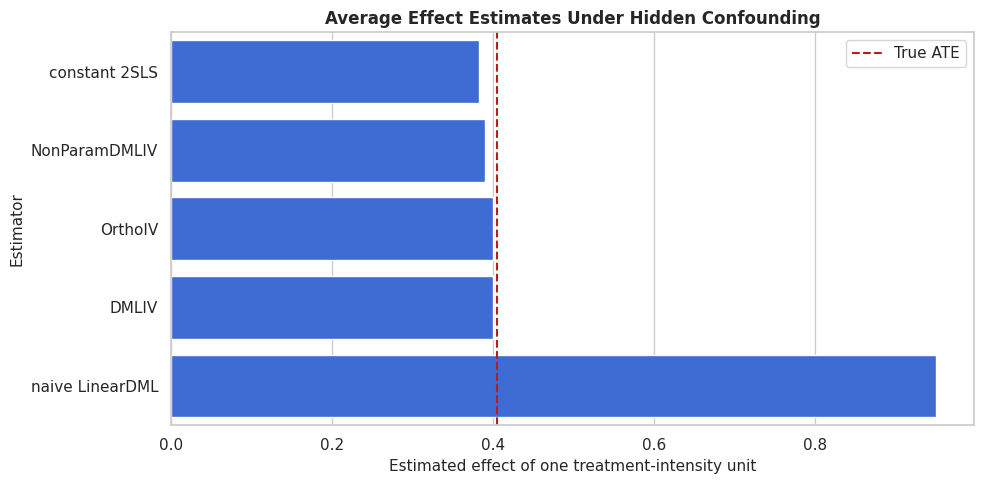

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_ate = estimator_comparison.sort_values("estimated_ate")
sns.barplot(data=plot_ate, x="estimated_ate", y="estimator", color="#2563eb", ax=ax)
ax.axvline(true_tau_iv_test.mean(), color="#b91c1c", linestyle="--", linewidth=1.5, label="True ATE")
ax.set_title("Average Effect Estimates Under Hidden Confounding")
ax.set_xlabel("Estimated effect of one treatment-intensity unit")
ax.set_ylabel("Estimator")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_iv_ate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The naive estimate is pulled upward by the hidden confounder. IV estimates are not perfect, but they are designed to target the causal effect using the instrument-induced treatment variation.

## CATE Recovery Plot

This plot compares row-level effect recovery for the main estimators. The constant 2SLS estimate is omitted because it has no row-level heterogeneity.

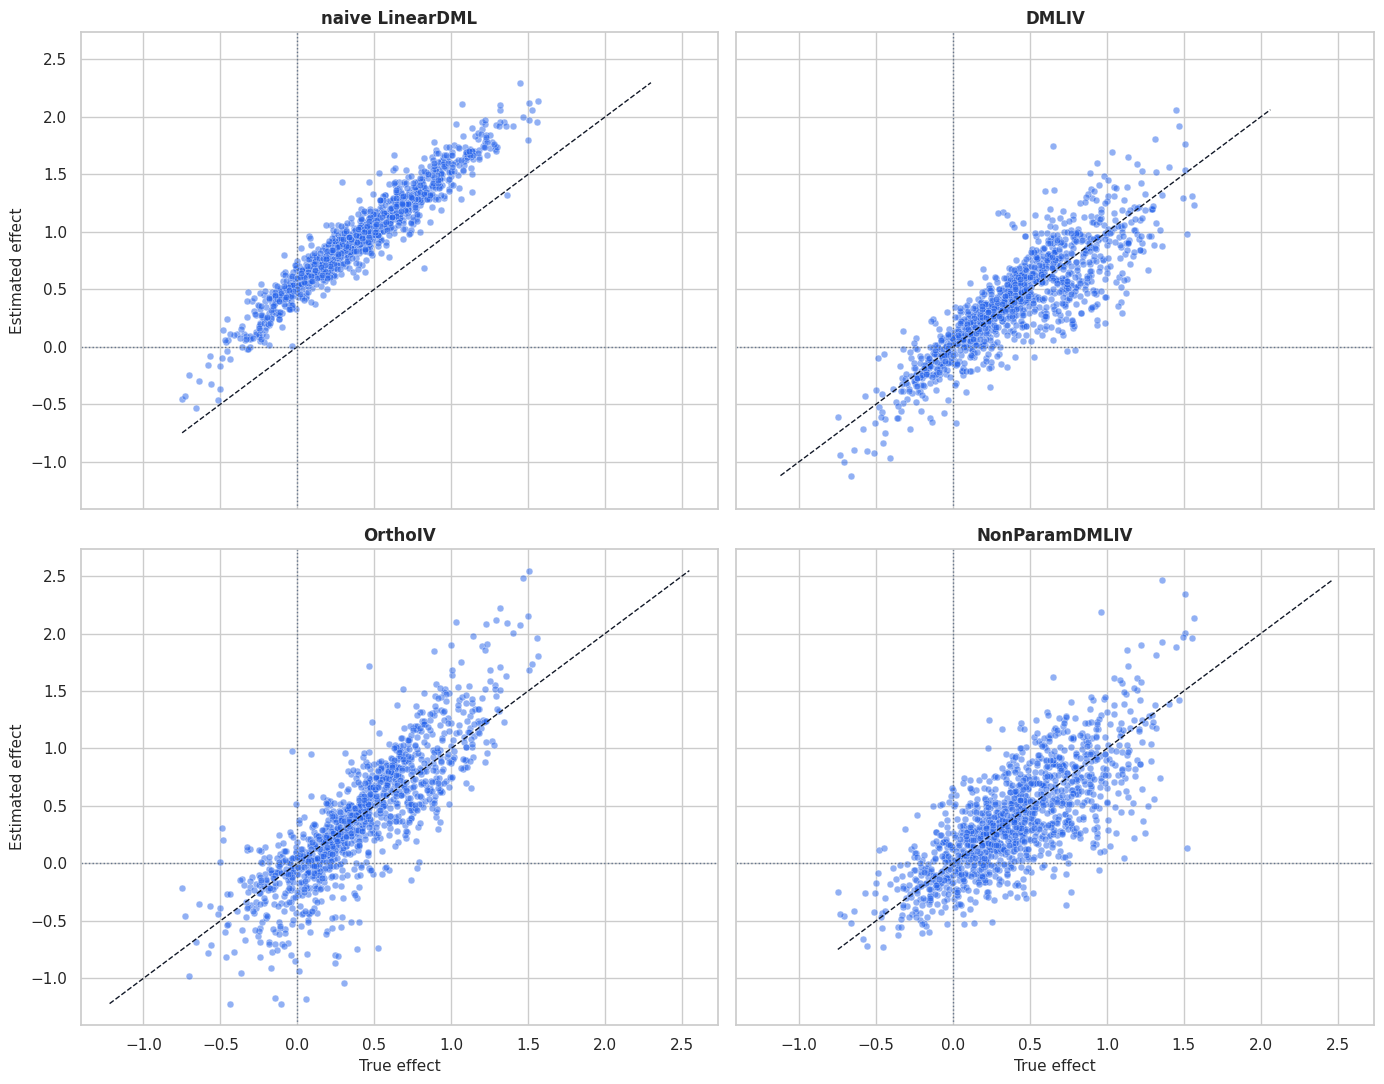

In [25]:
recovery_plot = effect_estimates.melt(
    id_vars="true_tau",
    value_vars=["naive_linear_dml", "dmliv", "orthoiv", "nonparam_dmliv"],
    var_name="estimator",
    value_name="estimated_tau",
)
recovery_plot["estimator"] = recovery_plot["estimator"].map(
    {
        "naive_linear_dml": "naive LinearDML",
        "dmliv": "DMLIV",
        "orthoiv": "OrthoIV",
        "nonparam_dmliv": "NonParamDMLIV",
    }
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
for ax, estimator in zip(axes.ravel(), recovery_plot["estimator"].unique()):
    subset = recovery_plot[recovery_plot["estimator"] == estimator]
    sns.scatterplot(data=subset, x="true_tau", y="estimated_tau", alpha=0.50, s=24, color="#2563eb", ax=ax)
    lims = [min(subset["true_tau"].min(), subset["estimated_tau"].min()), max(subset["true_tau"].max(), subset["estimated_tau"].max())]
    ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1)
    ax.axhline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.axvline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.set_title(estimator)
    ax.set_xlabel("True effect")
    ax.set_ylabel("Estimated effect")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_iv_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()

The panels show the difference between bias and heterogeneity recovery. A model can rank rows reasonably but still be shifted away from the causal level if hidden confounding remains.

## Segment-Level IV Effects

Segment summaries are useful for reporting IV results. Here we compare true and estimated effects by need and friction segments.

In [26]:
iv_segment_eval = iv_test[iv_feature_cols + ["true_tau", "treatment_intensity", "encouragement_score"]].copy()
iv_segment_eval["dmliv_effect"] = dmliv_effect
iv_segment_eval["orthoiv_effect"] = orthoiv_effect
iv_segment_eval["nonparam_dmliv_effect"] = nonparam_dmliv_effect
iv_segment_eval["naive_linear_dml_effect"] = naive_dml_effect
iv_segment_eval["need_segment"] = np.where(iv_segment_eval["baseline_need"] > iv_segment_eval["baseline_need"].median(), "higher need", "lower need")
iv_segment_eval["friction_segment"] = np.where(iv_segment_eval["friction_score"] > iv_segment_eval["friction_score"].median(), "higher friction", "lower friction")

segment_effect_summary = (
    iv_segment_eval.groupby(["need_segment", "friction_segment"], observed=True)
    .agg(
        rows=("true_tau", "size"),
        treatment_mean=("treatment_intensity", "mean"),
        instrument_mean=("encouragement_score", "mean"),
        true_effect_mean=("true_tau", "mean"),
        naive_effect_mean=("naive_linear_dml_effect", "mean"),
        dmliv_effect_mean=("dmliv_effect", "mean"),
        orthoiv_effect_mean=("orthoiv_effect", "mean"),
        nonparam_dmliv_effect_mean=("nonparam_dmliv_effect", "mean"),
    )
    .reset_index()
)

segment_effect_summary.to_csv(TABLE_DIR / "11_iv_segment_effect_summary.csv", index=False)
display(segment_effect_summary)

,need_segment,friction_segment,rows,treatment_mean,instrument_mean,true_effect_mean,naive_effect_mean,dmliv_effect_mean,orthoiv_effect_mean,nonparam_dmliv_effect_mean
0,higher need,higher friction,328,1.000961,0.125370,0.495348,1.060616,0.482898,0.469926,0.417156
1,higher need,lower friction,302,1.684295,0.431186,0.808843,1.356802,0.740908,0.862583,0.755324
2,lower need,higher friction,302,-0.096704,-0.503624,0.011051,0.513440,0.024708,-0.065795,-0.001614
3,lower need,lower friction,328,0.571939,-0.186142,0.305867,0.865808,0.348707,0.329170,0.384090


The segment table makes the IV results easier to read. It also shows whether estimators preserve the broad high-effect and low-effect segment ordering.

## Segment Effect Plot

This plot compares true effects with DMLIV and OrthoIV estimates by segment. It keeps the segment story compact.

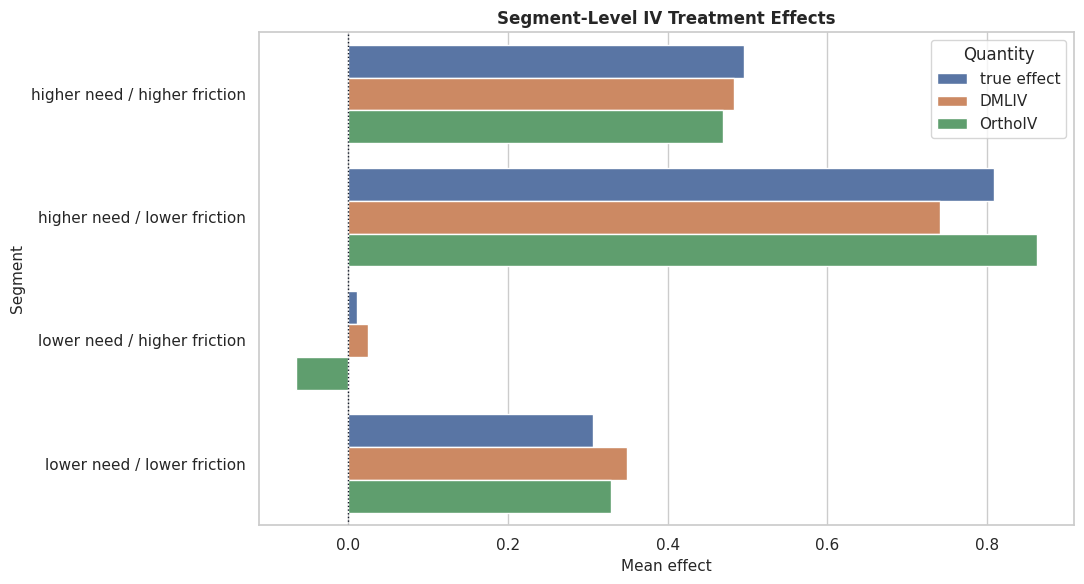

In [27]:
segment_plot = segment_effect_summary.copy()
segment_plot["segment"] = segment_plot["need_segment"] + " / " + segment_plot["friction_segment"]
segment_long = segment_plot.melt(
    id_vars="segment",
    value_vars=["true_effect_mean", "dmliv_effect_mean", "orthoiv_effect_mean"],
    var_name="quantity",
    value_name="effect",
)
segment_long["quantity"] = segment_long["quantity"].map(
    {
        "true_effect_mean": "true effect",
        "dmliv_effect_mean": "DMLIV",
        "orthoiv_effect_mean": "OrthoIV",
    }
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=segment_long, x="effect", y="segment", hue="quantity", ax=ax)
ax.axvline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Segment-Level IV Treatment Effects")
ax.set_xlabel("Mean effect")
ax.set_ylabel("Segment")
ax.legend(title="Quantity")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_iv_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()

The segment plot is a useful reporting artifact because it shows the practical effect pattern without overwhelming the reader with row-level estimates.

## Targeting By IV Effect

Even IV effects may be used for prioritization, but this should be done carefully because IV estimands describe instrument-induced variation. Here we compare top-20-percent targeting by different estimated effect scores against the synthetic truth.

In [28]:
top_share = 0.20
n_top = int(np.floor(top_share * len(effect_estimates)))

targeting_rows = []
for score_col, label in [
    ("naive_linear_dml", "Top 20% by naive LinearDML"),
    ("dmliv", "Top 20% by DMLIV"),
    ("orthoiv", "Top 20% by OrthoIV"),
    ("nonparam_dmliv", "Top 20% by NonParamDMLIV"),
]:
    selected_index = effect_estimates[score_col].nlargest(n_top).index
    selected = iv_test.loc[selected_index]
    targeting_rows.append(
        {
            "rule": label,
            "selected_rows": len(selected_index),
            "selected_share": len(selected_index) / len(effect_estimates),
            "mean_score_selected": effect_estimates.loc[selected_index, score_col].mean(),
            "mean_true_tau_selected": effect_estimates.loc[selected_index, "true_tau"].mean(),
            "share_high_need_selected": selected["high_need_segment"].mean(),
            "mean_friction_selected": selected["friction_score"].mean(),
        }
    )

targeting_summary = pd.DataFrame(targeting_rows)
targeting_summary.to_csv(TABLE_DIR / "11_iv_targeting_summary.csv", index=False)
display(targeting_summary)

,rule,selected_rows,selected_share,mean_score_selected,mean_true_tau_selected,share_high_need_selected,mean_friction_selected
0,Top 20% by naive LinearDML,252,0.2,1.567843,0.960964,0.821429,-0.561509
1,Top 20% by DMLIV,252,0.2,1.029343,0.888329,0.638889,-0.546538
2,Top 20% by OrthoIV,252,0.2,1.191845,0.907839,0.642857,-0.667665
3,Top 20% by NonParamDMLIV,252,0.2,1.085086,0.840929,0.599206,-0.514183


The targeting table shows how different estimators prioritize rows. IV-based targeting should always be described with care because the identified effect is tied to the instrument-induced treatment variation.

## Targeting Plot

The plot compares the true treatment effect among rows selected by each score. This is a teaching-only evaluation because real data do not reveal true row-level effects.

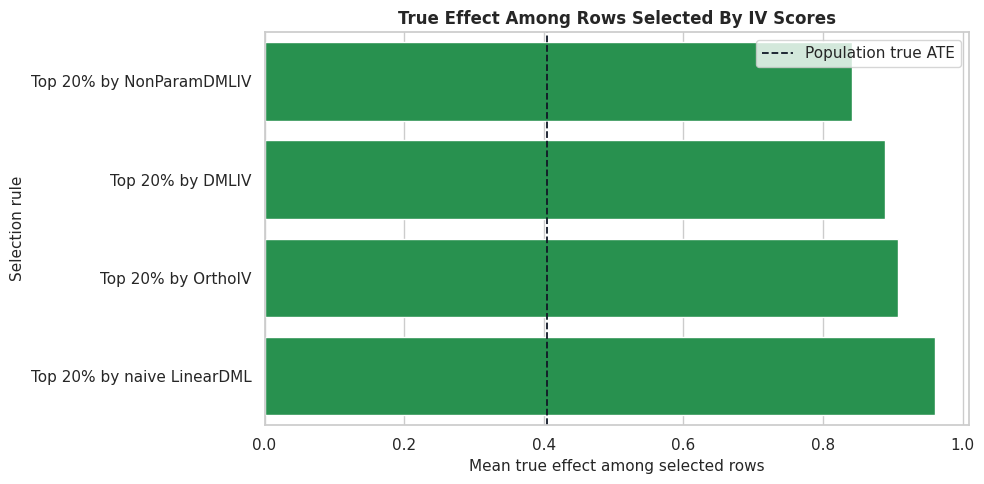

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=targeting_summary.sort_values("mean_true_tau_selected"), x="mean_true_tau_selected", y="rule", color="#16a34a", ax=ax)
ax.axvline(effect_estimates["true_tau"].mean(), color="#111827", linestyle="--", linewidth=1.3, label="Population true ATE")
ax.set_title("True Effect Among Rows Selected By IV Scores")
ax.set_xlabel("Mean true effect among selected rows")
ax.set_ylabel("Selection rule")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_iv_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()

The selected groups have higher true effects than the population average when the score captures useful heterogeneity. This is the decision-oriented side of CATE estimation.

## Weak Instrument Sensitivity

Weak instruments are a major IV failure mode. This cell keeps the same covariates and hidden confounder but changes the first-stage strength to show how first-stage diagnostics deteriorate.

In [30]:
weak_rows = []
for strength in [0.05, 0.15, 0.30, 0.50, first_stage_strength, 1.00]:
    treatment_alt = (
        0.90
        + strength * encouragement_score
        + 0.42 * baseline_need
        + 0.36 * prior_engagement
        - 0.24 * friction_score
        - 0.20 * price_sensitivity
        + 0.88 * hidden_motivation
        + rng.normal(0, 0.85, size=n_iv)
    )
    diag = residualized_first_stage(observed_features, treatment_alt, encouragement_score)
    weak_rows.append(
        {
            "first_stage_strength_parameter": strength,
            "residualized_beta": diag["beta"],
            "f_stat": diag["f_stat"],
            "partial_r2": diag["partial_r2"],
        }
    )

weak_instrument_sensitivity = pd.DataFrame(weak_rows)
weak_instrument_sensitivity.to_csv(TABLE_DIR / "11_weak_instrument_sensitivity.csv", index=False)
display(weak_instrument_sensitivity)

,first_stage_strength_parameter,residualized_beta,f_stat,partial_r2
0,0.05,0.062799,9.995192,0.002770
1,0.15,0.175026,77.902067,0.021193
2,0.30,0.317874,252.427100,0.065558
3,0.50,0.508045,669.427703,0.156869
4,0.72,0.738203,1374.998014,0.276493
5,1.00,1.006623,2505.401378,0.410493


As the instrument's effect on treatment weakens, the first-stage F-statistic and partial R-squared fall. Weak instruments make IV estimates unstable because there is little instrument-induced treatment variation to use.

## Weak Instrument Plot

The plot turns the weak-instrument table into a quick visual diagnostic.

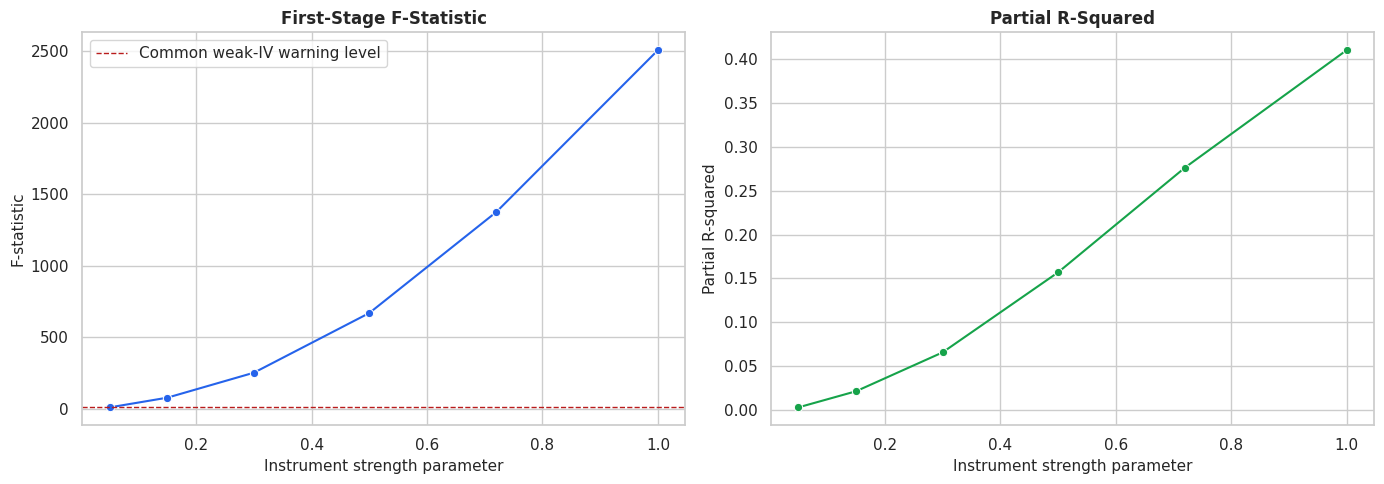

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=weak_instrument_sensitivity, x="first_stage_strength_parameter", y="f_stat", marker="o", color="#2563eb", ax=axes[0])
axes[0].axhline(10, color="#b91c1c", linestyle="--", linewidth=1, label="Common weak-IV warning level")
axes[0].set_title("First-Stage F-Statistic")
axes[0].set_xlabel("Instrument strength parameter")
axes[0].set_ylabel("F-statistic")
axes[0].legend()

sns.lineplot(data=weak_instrument_sensitivity, x="first_stage_strength_parameter", y="partial_r2", marker="o", color="#16a34a", ax=axes[1])
axes[1].set_title("Partial R-Squared")
axes[1].set_xlabel("Instrument strength parameter")
axes[1].set_ylabel("Partial R-squared")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "11_weak_instrument_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The warning line is a rough rule of thumb rather than a universal guarantee. The broader lesson is that weak instruments create fragile estimates even if the exclusion story sounds plausible.

## Exclusion Violation Sensitivity

The exclusion restriction says that the instrument affects the outcome only through treatment. This assumption is not directly testable. The simple table below shows the intuition: even a small direct effect of `Z` on `Y` can translate into IV bias when divided by the first-stage strength.

In [32]:
first_stage_beta = first_stage_summary.loc[first_stage_summary["diagnostic"] == "residualized_first_stage_beta", "value"].iloc[0]
exclusion_rows = []
for direct_effect in [0.00, 0.03, 0.06, 0.10, 0.15]:
    approximate_iv_bias = direct_effect / first_stage_beta
    exclusion_rows.append(
        {
            "direct_z_to_y_effect": direct_effect,
            "first_stage_beta_used": first_stage_beta,
            "approximate_iv_bias": approximate_iv_bias,
            "true_ate_plus_approximate_bias": true_tau_iv_test.mean() + approximate_iv_bias,
        }
    )

exclusion_sensitivity = pd.DataFrame(exclusion_rows)
exclusion_sensitivity.to_csv(TABLE_DIR / "11_exclusion_violation_sensitivity.csv", index=False)
display(exclusion_sensitivity)

,direct_z_to_y_effect,first_stage_beta_used,approximate_iv_bias,true_ate_plus_approximate_bias
0,0.00,0.719671,0.000000,0.405085
1,0.03,0.719671,0.041686,0.446770
2,0.06,0.719671,0.083371,0.488456
3,0.10,0.719671,0.138952,0.544037
4,0.15,0.719671,0.208429,0.613513


This is not a replacement for a design argument. It is a reminder that IV estimates can be very sensitive to direct instrument-outcome paths, especially when the first stage is not strong.

## Practical IV Reporting Checklist

A credible IV report should not just present an estimate. It should explain why the instrument is relevant, why independence and exclusion are plausible, how strong the first stage is, and what population the estimand represents.

In [33]:
iv_reporting_checklist = pd.DataFrame(
    [
        {
            "topic": "Instrument definition",
            "what_to_report": "Explain exactly how Z is assigned or generated.",
            "why_it_matters": "The design story is the source of IV credibility.",
        },
        {
            "topic": "Relevance",
            "what_to_report": "Report first-stage coefficient, F-statistic, and partial R-squared after adjusting for X.",
            "why_it_matters": "Weak instruments produce unstable estimates.",
        },
        {
            "topic": "Independence",
            "what_to_report": "Show covariate balance or explain conditional as-if randomness.",
            "why_it_matters": "If Z is confounded, IV does not solve the identification problem.",
        },
        {
            "topic": "Exclusion",
            "what_to_report": "Discuss why Z should not affect Y except through T and use placebo checks if possible.",
            "why_it_matters": "Direct Z-to-Y effects bias IV estimates.",
        },
        {
            "topic": "Estimator choice",
            "what_to_report": "State whether results use DMLIV, OrthoIV, NonParamDMLIV, or another IV estimator.",
            "why_it_matters": "Different estimators have different final-stage flexibility and assumptions.",
        },
        {
            "topic": "Target population",
            "what_to_report": "Clarify whether the effect is local to instrument-responsive units.",
            "why_it_matters": "IV effects may not describe units whose treatment never responds to the instrument.",
        },
        {
            "topic": "Sensitivity",
            "what_to_report": "Discuss weak-instrument and exclusion-violation sensitivity.",
            "why_it_matters": "The main IV risks are design risks, not just model risks.",
        },
    ]
)

iv_reporting_checklist.to_csv(TABLE_DIR / "11_iv_reporting_checklist.csv", index=False)
display(iv_reporting_checklist)

,topic,what_to_report,why_it_matters
0,Instrument definition,Explain exactly how Z is assigned or generated.,The design story is the source of IV credibility.
1,Relevance,"Report first-stage coefficient, F-statistic, a...",Weak instruments produce unstable estimates.
2,Independence,Show covariate balance or explain conditional ...,"If Z is confounded, IV does not solve the iden..."
3,Exclusion,Discuss why Z should not affect Y except throu...,Direct Z-to-Y effects bias IV estimates.
4,Estimator choice,"State whether results use DMLIV, OrthoIV, NonP...",Different estimators have different final-stag...
5,Target population,Clarify whether the effect is local to instrum...,IV effects may not describe units whose treatm...
6,Sensitivity,Discuss weak-instrument and exclusion-violatio...,"The main IV risks are design risks, not just m..."


The checklist is deliberately design-heavy. IV methods are powerful only when the instrument is credible.

## Summary

This notebook introduced instrumental-variable estimation in EconML.

The main lessons are:

- Ordinary adjustment can be biased when treatment is driven by an unobserved confounder.
- A valid instrument creates treatment variation that is not driven by the hidden confounder.
- Instrument relevance can be diagnosed with residualized first-stage checks.
- Instrument independence and exclusion require a design argument; they are not guaranteed by model fit.
- `DMLIV`, `OrthoIV`, and `NonParamDMLIV` provide runnable IV workflows in this environment.
- DeepIV is conceptually useful for flexible continuous-treatment IV problems, but it is not available in this local package setup.
- Weak or invalid instruments can produce misleading estimates, so IV results should always be reported with assumption checks and sensitivity discussion.

The next tutorial discusses repeated observations and longitudinal extensions, where timing and treatment history become central.